# Visualizing Linear Anti-Aliasing Between Two Points

In this example we will use WxData to:

1) Download the latest Observed Sounding Data for OUN
2) Use Matplotlib to plot Temperature vs. Pressure without Linear Anti-Aliasing
3) Use `linear_anti_aliasing()` to interpolate 100 data points between each data point in the observed sounding data
4) Use Matplotlib to plot Temperature vs. Pressure with LinearAnti-Aliasing

# Imports

In [1]:
import matplotlib.pyplot as plt

from wxdata import(
    get_observed_sounding_data,
    linear_anti_aliasing
)

# Use `get_observed_sounding_data()` To Retrieve Latest OUN Sounding Data

In [2]:
df, date = get_observed_sounding_data('oun')

In [3]:
df

,PRES,HGHT,TEMP,DWPT,DRCT,SKNT,U-WIND,V-WIND,RH,THETA,BVF,WET-BULB
2,970.0,396.0,11.4,5.4,180.0,10.0,-1.224647e-15,1.000000e+01,66.570805,287.037140,0.028562,8.235201
3,951.0,563.0,17.0,6.0,213.0,27.0,1.470525e+01,2.264411e+01,48.277782,294.345034,0.033034,10.838466
4,947.0,598.0,17.7,5.2,220.0,30.0,1.928363e+01,2.298133e+01,43.695039,295.410697,0.031872,10.757084
5,938.0,680.0,19.4,3.4,237.0,29.0,2.432145e+01,1.579453e+01,34.625460,297.949149,0.021353,10.668668
6,936.0,698.0,19.4,2.4,241.0,29.0,2.536397e+01,1.405948e+01,32.256524,298.130908,0.042701,10.283279
...,...,...,...,...,...,...,...,...,...,...,...,...
162,7.6,32496.0,-47.1,-84.1,264.0,43.0,4.276444e+01,4.494724e+00,0.618769,911.352401,0.020419,-54.570836
163,7.3,32762.0,-48.1,-84.1,267.0,49.0,4.893285e+01,2.564462e+00,0.692182,917.821443,0.020455,-55.249440
164,7.0,33040.0,-47.1,-84.1,270.0,55.0,5.500000e+01,1.010334e-14,0.618769,933.019640,0.027142,-54.897799
165,6.9,33135.0,-46.3,-83.3,270.0,55.0,5.500000e+01,1.010334e-14,0.647846,940.178839,0.024973,-54.546802


In [4]:
date

datetime.datetime(2026, 3, 19, 12, 0)

# Plot the Raw Observed Temperature vs. Pressure Data With Matplotlib

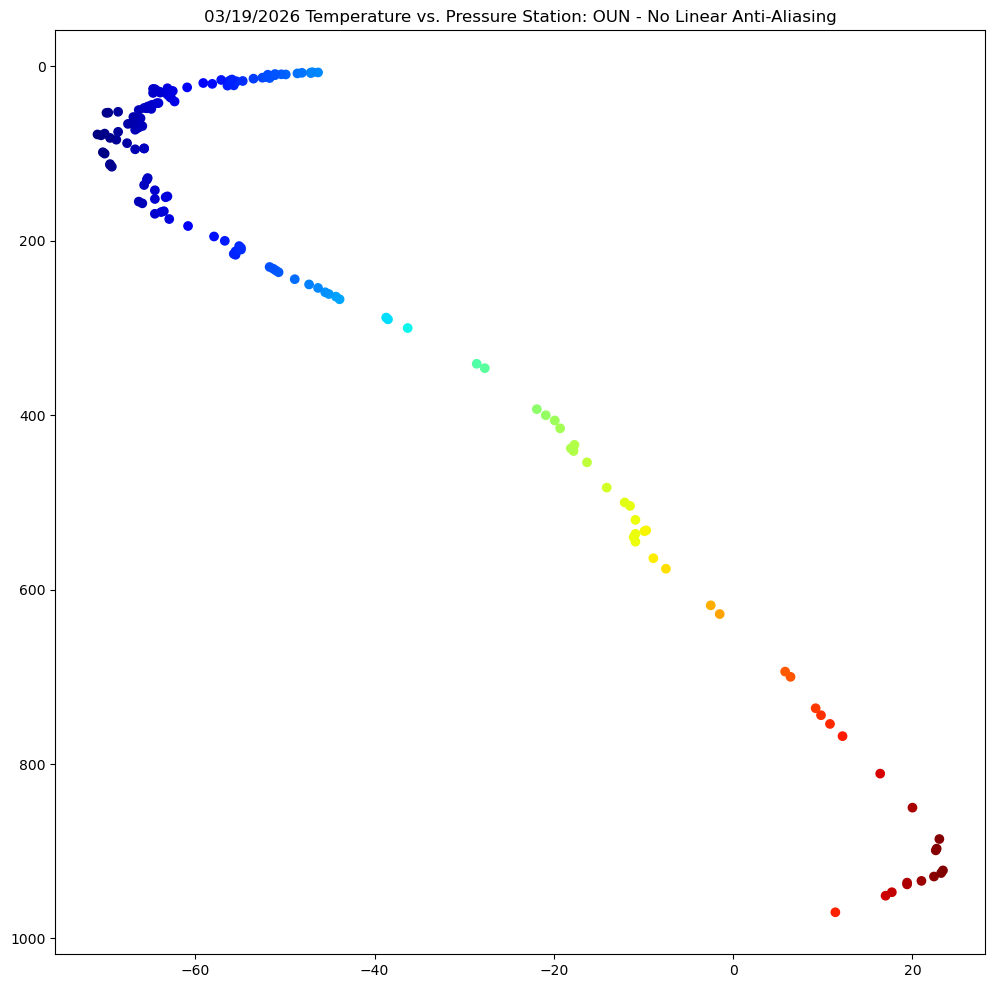

In [5]:
# Create figure object
fig = plt.figure(figsize=(12,12))

# Create out axis for our plot
ax = fig.add_subplot(1,1,1)

# Create Out Title
ax.set_title(f"{date.strftime('%m/%d/%Y')} Temperature vs. Pressure Station: OUN - No Linear Anti-Aliasing")

# Invert our y-axis
ax.invert_yaxis()

# Plot our data
ax.scatter(df['TEMP'], 
           df['PRES'], 
           c=df['TEMP'],
           cmap='jet')

# Using `linear_anti_aliasing()` From WxData

We will now use `linear_anti_aliasing()` to interpolate 100 data points between each observed point

In [6]:
anti_aliasing = 100

temp_x, temp_y = linear_anti_aliasing(df['TEMP'], 
                                     df['PRES'], 
                                     anti_aliasing)

In [7]:
temp_x

array([ 11.4       ,  11.45656566,  11.51313131, ..., -46.88787879,
       -46.89393939, -46.9       ], shape=(16200,))

In [8]:
temp_y

array([970.        , 969.80808081, 969.61616162, ...,   6.7040404 ,
         6.7020202 ,   6.7       ], shape=(16200,))

# Plot the Raw Observed Temperature With Linear Anti-Aliasing vs. Pressure Data With Matplotlib

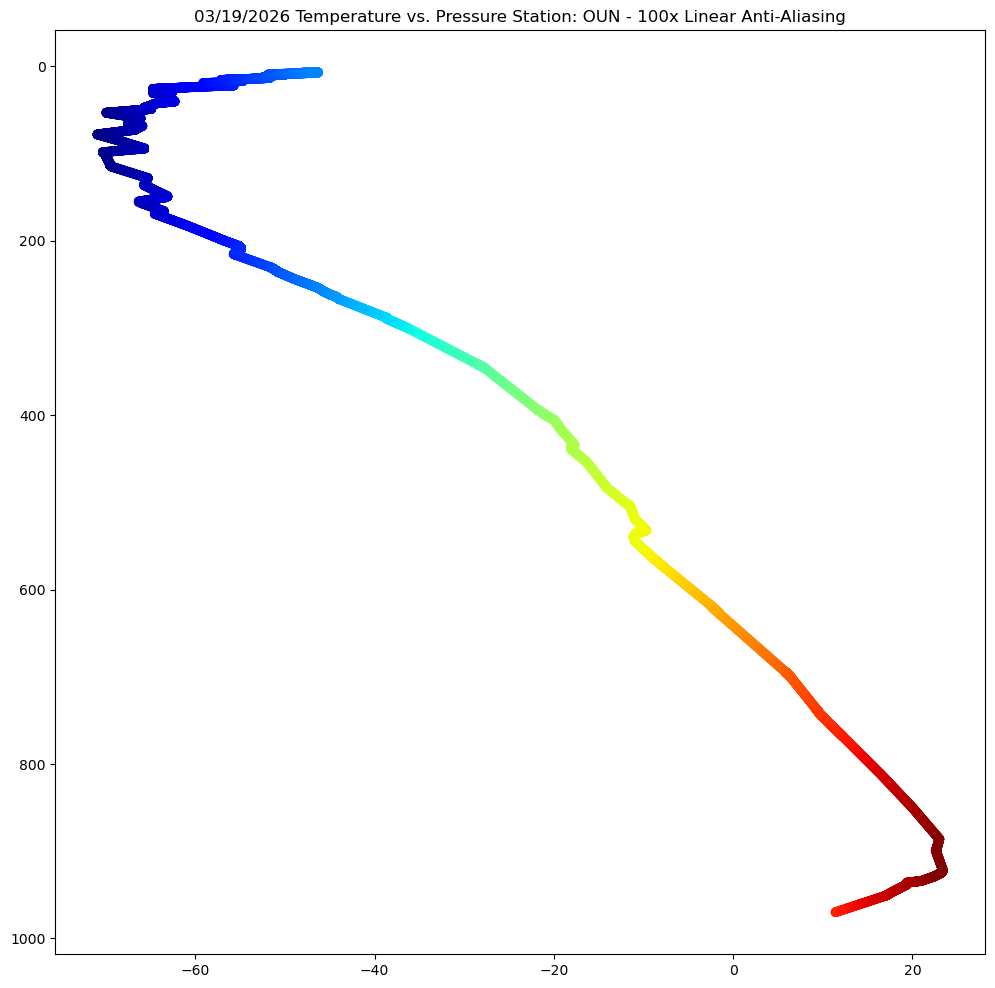

In [9]:
# Create figure object
fig = plt.figure(figsize=(12,12))

# Create out axis for our plot
ax = fig.add_subplot(1,1,1)

# Create Out Title
ax.set_title(f"{date.strftime('%m/%d/%Y')} Temperature vs. Pressure Station: OUN - 100x Linear Anti-Aliasing")

# Invert our y-axis
ax.invert_yaxis()

# Plot our data
ax.scatter(temp_x, 
           temp_y, 
           c=temp_x,
           cmap='jet')